In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ============================================================================
# CELDA COLAB — Ejecutar PRIMERO en Google Colab (saltar en local)
# ============================================================================
# 1. Monta Google Drive:
#    from google.colab import drive; drive.mount('/content/drive')
# 2. Navega al repo:
#    import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
# 3. Ejecuta esta celda → instala dependencias automáticamente si está en Colab
#
# PRERREQUISITO: ejecutar 00_eda_preprocessing.ipynb para crear data/processed/
# ============================================================================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    print('Colab detectado — instalando dependencias...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', 'pvlib', '--quiet'],
        check=True
    )
    print('✓ Dependencias instaladas')
else:
    print('Entorno local — sin instalaciones adicionales')

Colab detectado — instalando dependencias...
✓ Dependencias instaladas


In [3]:
# ============================================================================
# BASELINE CON LSTM - FORECASTING SOLAR
# Dataset: 14 plantas fotovoltaicas, año 2025
# ============================================================================

import sys
# Añadir src/ al path buscando la raíz del repo desde el directorio actual.
# En Google Colab: montar Drive y hacer os.chdir() al repo ANTES de ejecutar.
#   from google.colab import drive; drive.mount('/content/drive')
#   import os; os.chdir('/content/drive/MyDrive/.../tfm-solar-forecasting/')
import pathlib as _pl
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f"No se encontró src/. cwd={_pl.Path.cwd()}\n"
        "En Colab: monta Drive y ejecuta os.chdir() al repo antes de %run."
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch

# Módulos custom
from data_processing import SolarDataProcessor
from data_loaders import create_dataloaders, SolarSequenceDataset
from lstm_model import LSTMForecaster, LSTMTrainer
from models import train_with_kfold, predict_ensemble, plot_kfold_curves
from evaluation import ForecastEvaluator

# Módulo de armonización ex1_compare
from ex1_compare import PLANTAS, SMOKE_TEST, SMOKE_MAX_ROWS, DEVICE, DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR
from ex1_compare import plot_diagnostic, plot_timeseries, plot_model_comparison, plot_learning_curves
from ex1_compare import ResultsManager

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

device = DEVICE
print(f"Usando device: {device}")

%matplotlib inline

# Inicializar gestor de resultados
rm = ResultsManager('lstm', results_dir=RESULTS_DIR, checkpoints_dir=CHECKPOINTS_DIR)

print("="*80)
print("EXPERIMENTO 1b: BASELINE CON LSTM")
print(f"Plantas: {PLANTAS}")
print(f"Smoke test: {SMOKE_TEST}")
print("="*80)

[ex1] Entorno: Google Colab | Device: cuda (Tesla T4)
Usando device: cuda
ResultsManager [lstm]
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm
  Metricas:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/lstm
EXPERIMENTO 1b: BASELINE CON LSTM
Plantas: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']
Smoke test: False


In [4]:
# ============================================================================
# 1. CARGAR DATOS PROCESADOS
# ============================================================================

print("\n[1/5] Cargando datos procesados...")

# Cargar splits ya procesados (del experimento Prophet)
df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_val   = pd.read_csv(DATA_DIR / 'val.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f"✓ Datos cargados")
print(f"  Train: {len(df_train):,} registros")
print(f"  Val:   {len(df_val):,} registros")
print(f"  Test:  {len(df_test):,} registros")

# Plantas disponibles
plantas = sorted(df_train['planta_nombre'].unique())
print(f"\nPlantas: {len(plantas)}")
for p in plantas:
    print(f"  - {p}")


[1/5] Cargando datos procesados...
✓ Datos cargados
  Train: 50,917 registros
  Val:   6,780 registros
  Test:  8,922 registros

Plantas: 6
  - FVARENA
  - NBALBOA
  - RODRI
  - TALASOL
  - UFMULA
  - UPGARNACHA


In [5]:
# Cargar métricas de Prophet para comparación
prophet_path = rm.metrics_dir / 'prophet_metrics_summary.csv'
if not prophet_path.exists():
    prophet_path = Path('../results/metrics/prophet_metrics_summary.csv')
df_metrics_prophet = pd.read_csv(prophet_path) if prophet_path.exists() else pd.DataFrame()

In [ ]:
# ============================================================================
# CELDA 2 — Configuración
# ============================================================================

FEATURE_COLS = [
    'shortwave_radiation', 'direct_normal_irradiance',
    'global_tilted_irradiance', 'cloud_cover', 'temperature_2m',
    'elevacion_solar', 'azimut_solar', 'hora', 'dia_semana',
    'mes', 'dia_año', 'es_dia'
]

FUTURE_FEATURE_COLS = [
    'shortwave_radiation', 'direct_normal_irradiance',
    'global_tilted_irradiance', 'cloud_cover',
    'elevacion_solar', 'hora', 'es_dia',
]

# lag_168h añadido: captura el patrón de la misma hora de la semana anterior
LAG_STEPS = [1, 2, 3, 24, 48, 168]

PARAMS_BASE = {
    'seq_length':          48,
    'hidden_size':         32,
    'num_layers':           2,
    'dropout':            0.4,
    'noise_std':          0.05,
    'batch_size':          64,
    'learning_rate':    0.001,
    'epochs':             200,
    'patience':            40,
    'n_future_features': len(FUTURE_FEATURE_COLS),
    'loss_alpha':         0.7,
    'use_kfold':          False,
    'n_splits':             3,
    'lag_steps':  LAG_STEPS,
}

# hidden_size=64 para plantas grandes (≥300 MW): mayor capacidad para
# varianzas altas. FVARENA y RODRI (<200 MW) usan el default (32).
PARAMS_PER_PLANT = {
    'NBALBOA': {**PARAMS_BASE, 'hidden_size': 64},   # 499 MW
    'UFMULA':  {**PARAMS_BASE, 'hidden_size': 64},   # 494 MW
    'TALASOL': {**PARAMS_BASE, 'hidden_size': 64},   # 300 MW
}

print(f"Features históricas: {len(FEATURE_COLS)}")
print(f"Lag features:        {len(LAG_STEPS)} → {LAG_STEPS}")
print(f"Features objetivo:   {len(FUTURE_FEATURE_COLS)}")
print(f"hidden_size base:    {PARAMS_BASE['hidden_size']}  |  grandes (≥300 MW): 64")
print(f"Modo:                {'K-Fold ensemble' if PARAMS_BASE['use_kfold'] else 'Split fijo (sin K-Fold)'}")
if PARAMS_BASE['use_kfold']:
    print(f"  n_splits: {PARAMS_BASE['n_splits']}")


In [7]:
# ============================================================================
# CELDA 4 — Entrenamiento con las 4 correcciones del K-Fold
# ============================================================================

import time

print(f"\n[3/5] Entrenamiento LSTM v4 (kfold corregido)")
print("=" * 80)

_HAS_VALID = 'valid_data' in df_train.columns

all_models      = {}
all_fold_hists  = {}   # planta -> fold_histories (para diagnóstico)
scalers         = {}
results_all     = []
training_times  = {}   # planta → segundos de entrenamiento

plantas_p = PLANTAS

for i, planta in enumerate(plantas_p, 1):
    print(f"\n{'=' * 80}")
    P = PARAMS_PER_PLANT.get(planta, PARAMS_BASE)
    planta_info = df_train[df_train['planta_nombre'] == planta].iloc[0]
    print(f"PLANTA {i}/{len(plantas_p)}: {planta}  "
          f"({planta_info['instalada_mw']:.0f} MW  {planta_info['zona_climatica']})  "
          f"modo={'K-Fold n='+str(P['n_splits']) if P['use_kfold'] else 'Split fijo'}  "
          f"loss_alpha={P['loss_alpha']}")
    print(f"{'=' * 80}")

    df_train_dia = df_train[(df_train['planta_nombre'] == planta) & (df_train['es_dia'] == 1)]
    df_val_dia   = df_val[(df_val['planta_nombre']   == planta) & (df_val['es_dia']   == 1)]
    df_test_dia  = df_test[(df_test['planta_nombre'] == planta) & (df_test['es_dia']  == 1)]
    print(f"Diurnas: train={len(df_train_dia):,}  val={len(df_val_dia):,}  test={len(df_test_dia):,}")
    # Las ventanas con valid_data=False son filtradas automáticamente por SolarSequenceDataset

    (train_loader, val_loader, test_loader,
     scaler_x, scaler_y, lag_builder, n_feat_total) = create_dataloaders(
        df_train_dia, df_val_dia, df_test_dia,
        planta_nombre=planta,
        feature_cols=FEATURE_COLS,
        future_feature_cols=FUTURE_FEATURE_COLS,
        lag_steps=P['lag_steps'],
        seq_length=P['seq_length'],
        batch_size=P['batch_size']
    )
    scalers[planta] = (scaler_x, scaler_y, lag_builder)

    def make_model(P=P, n_feat_total=n_feat_total):
        return LSTMForecaster(
            n_features=n_feat_total,
            n_future_features=P['n_future_features'],
            hidden_size=P['hidden_size'],
            num_layers=P['num_layers'],
            dropout=P['dropout'],
            noise_std=P['noise_std']
        )

    def make_trainer(model, P=P):
        return LSTMTrainer(
            model, device=device,
            learning_rate=P['learning_rate'],
            loss_alpha=P['loss_alpha']
        )

    n_params = sum(p.numel() for p in make_model().parameters() if p.requires_grad)
    print(f"Modelo: {n_params:,} params  ratio={n_params/len(train_loader.dataset):.1f}x  "
          f"n_features={n_feat_total}")

    # ── Dataset de test ───────────────────────────────────────────────────────
    test_ds = SolarSequenceDataset(
        df_test_dia, planta, FEATURE_COLS,
        future_feature_cols=FUTURE_FEATURE_COLS,
        lag_steps=P['lag_steps'],
        seq_length=P['seq_length'],
        scaler_x=scaler_x, scaler_y=scaler_y, lag_builder=lag_builder
    )

    t0 = time.time()

    if P['use_kfold']:
        # ── MODO K-FOLD (corregido) ───────────────────────────────────────────
        df_tv = pd.concat([df_train_dia, df_val_dia]).sort_values('timestamp_utc')
        all_ds = SolarSequenceDataset(
            df_tv, planta, FEATURE_COLS,
            future_feature_cols=FUTURE_FEATURE_COLS,
            lag_steps=P['lag_steps'],
            seq_length=P['seq_length'],
            scaler_x=scaler_x, scaler_y=scaler_y, lag_builder=lag_builder
        )
        print(f"\nK-Fold ({P['n_splits']} folds, shuffle=True) sobre "
              f"{len(all_ds):,} secuencias...")

        models_kfold, fold_hists = train_with_kfold(
            all_ds, make_model, make_trainer,
            n_splits=P['n_splits'],
            epochs=P['epochs'], patience=P['patience'],
            batch_size=P['batch_size'], device=device, verbose=True
        )

        all_models[planta]     = models_kfold
        all_fold_hists[planta] = fold_hists

        # Guardar checkpoint del mejor fold
        best_fold_idx = min(range(len(fold_hists)),
                           key=lambda j: fold_hists[j].get('best_val_loss',
                                         fold_hists[j].get('best_val_mae', float('inf'))))
        rm.save_checkpoint(models_kfold[best_fold_idx], planta)

        # Ensemble ponderado
        print(f"\nEnsemble ponderado...")
        df_pred = predict_ensemble(models_kfold, fold_hists, test_ds, device=device)

    else:
        # ── MODO SPLIT FIJO ────────────────────
        model   = make_model()
        trainer = make_trainer(model)
        print(f"\nEntrenando (split fijo)...")
        trainer.fit(train_loader, val_loader,
                    epochs=P['epochs'], patience=P['patience'], verbose=True)

        all_models[planta]     = trainer
        all_fold_hists[planta] = None

        # Guardar checkpoint
        rm.save_checkpoint(trainer.model, planta)

        df_pred = test_ds.get_full_predictions(trainer.model, device=device)

    training_times[planta] = time.time() - t0
    print(f"  Tiempo entrenamiento: {training_times[planta]/60:.1f} min ({training_times[planta]:.0f} s)")

    # ── Completar con horas nocturnas (y_pred = 0.0) ──────────────────────────
    df_test_planta = df_test[df_test['planta_nombre'] == planta][
        ['timestamp_utc', 'produccion', 'planta_nombre']
    ].copy()
    df_test_planta = df_test_planta.rename(
        columns={'timestamp_utc': 'timestamp', 'produccion': 'y_true'}
    )
    df_test_planta['timestamp'] = df_test_planta['timestamp'].astype(str).str[:19]
    df_pred['timestamp'] = df_pred['timestamp'].astype(str).str[:19]
    df_pred = df_test_planta.merge(df_pred[['timestamp', 'y_pred']], on='timestamp', how='left')
    df_pred['y_pred'] = df_pred['y_pred'].fillna(0.0)

    # ── Añadir metadatos (incluyendo valid_data si existe) ────────────────────
    _meta_cols = ['timestamp_utc', 'planta_nombre', 'hora', 'mes',
                  'cloud_cover', 'estacion', 'zona_climatica']
    if _HAS_VALID:
        _meta_cols.append('valid_data')
    df_pred = df_pred.merge(
        df_test[[c for c in _meta_cols if c in df_test.columns]],
        left_on=['timestamp', 'planta_nombre'],
        right_on=['timestamp_utc', 'planta_nombre'], how='left'
    )
    results_all.append(df_pred)

    # ── Métricas (solo horas válidas) ─────────────────────────────────────────
    if _HAS_VALID and 'valid_data' in df_pred.columns:
        df_pred_eval = df_pred[df_pred['valid_data'].fillna(True).astype(bool)]
        n_excl = len(df_pred) - len(df_pred_eval)
        if n_excl > 0:
            print(f"  ⚠ {n_excl} horas excluidas de métricas test (valid_data=False)")
    else:
        df_pred_eval = df_pred

    m = ForecastEvaluator.calculate_metrics(
        df_pred_eval['y_true'].values, df_pred_eval['y_pred'].values, planta_nombre=planta)

    # Referencia Prophet para comparación inmediata
    prophet_mae = df_metrics_prophet[df_metrics_prophet['planta'] == planta]['MAE'].values if len(df_metrics_prophet) > 0 else []
    ref = f"  Prophet MAE={prophet_mae[0]:.1f}" if len(prophet_mae) > 0 else ""
    gap_vs_prophet = m['MAE'] - prophet_mae[0] if len(prophet_mae) > 0 else float('nan')

    print(f"\nMETRICAS TEST ({planta}):")
    print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  "
          f"MAPE={m['MAPE']:.2f}%  R2={m['R2']:.4f}")
    if len(prophet_mae) > 0:
        print(f"  vs Prophet: MAE gap={gap_vs_prophet:+.2f}{ref}")

df_results = pd.concat(results_all, ignore_index=True)
rm.save_predictions(df_results)



[3/5] Entrenamiento LSTM v4 (kfold corregido)

PLANTA 1/6: UPGARNACHA  (149 MW  Norte)  modo=Split fijo  loss_alpha=0.7
Diurnas: train=3,233  val=535  test=573

DataLoaders — UPGARNACHA:
  Train : 3,129 secuencias
  Val   : 487 secuencias
  Test  : 525 secuencias
  Features base: 12  |  Lags: 6  |  Total: 18
  SolarScaler → mean=164.5 MW, std=165.2 MW
Modelo: 15,794 params  ratio=5.0x  n_features=18

Entrenando (split fijo)...


Training:  50%|█████     | 100/200 [00:34<00:34,  2.87it/s, best=0.2398, lr=1.3e-04, train=0.1180, val=0.2446]



Early stopping época 101

✓ Completado  |  best val_loss: 0.239751
  Checkpoint guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/lstm/UPGARNACHA.pt
  Tiempo entrenamiento: 0.7 min (42 s)

METRICAS TEST (UPGARNACHA):
  MAE=27.02  RMSE=58.98  MAPE=89.01%  R2=0.4785
  vs Prophet: MAE gap=-15.10  Prophet MAE=42.1

PLANTA 2/6: FVARENA  (150 MW  Centro)  modo=Split fijo  loss_alpha=0.7
Diurnas: train=4,479  val=538  test=596

DataLoaders — FVARENA:
  Train : 4,257 secuencias
  Val   : 490 secuencias
  Test  : 548 secuencias
  Features base: 12  |  Lags: 6  |  Total: 18
  SolarScaler → mean=65.7 MW, std=78.1 MW
Modelo: 15,794 params  ratio=3.7x  n_features=18

Entrenando (split fijo)...


Training:  20%|██        | 40/200 [00:18<01:12,  2.21it/s, best=0.9357, lr=2.5e-04, train=0.2396, val=1.2710]



Early stopping época 41

✓ Completado  |  best val_loss: 0.935659
  Checkpoint guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/lstm/FVARENA.pt
  Tiempo entrenamiento: 0.3 min (18 s)

METRICAS TEST (FVARENA):
  MAE=28.97  RMSE=58.76  MAPE=90.90%  R2=0.1016
  vs Prophet: MAE gap=+4.36  Prophet MAE=24.6

PLANTA 3/6: NBALBOA  (499 MW  Centro)  modo=Split fijo  loss_alpha=0.7
Diurnas: train=4,477  val=537  test=611

DataLoaders — NBALBOA:
  Train : 4,179 secuencias
  Val   : 489 secuencias
  Test  : 444 secuencias
  Features base: 12  |  Lags: 6  |  Total: 18
  SolarScaler → mean=284.5 MW, std=330.6 MW
Modelo: 56,018 params  ratio=13.4x  n_features=18

Entrenando (split fijo)...


...

Training:  27%|██▋       | 80/300 [00:36<01:39,  2.20it/s, best=0.4164, lr=2.5e-04, train=0.1235, val=0.4698]



Early stopping época 81

✓ Completado  |  best val_loss: 0.416402
  Checkpoint guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/lstm/UFMULA.pt
  Tiempo entrenamiento: 0.6 min (37 s)

METRICAS TEST (UFMULA):
  MAE=117.16  RMSE=240.22  MAPE=70.57%  R2=0.6390
  vs Prophet: MAE gap=+20.33  Prophet MAE=96.8

PLANTA 6/6: TALASOL  (301 MW  Centro)  modo=Split fijo  loss_alpha=0.7
Diurnas: train=4,477  val=537  test=592

DataLoaders — TALASOL:
  Train : 4,000 secuencias
  Val   : 364 secuencias
  Test  : 544 secuencias
  Features base: 12  |  Lags: 6  |  Total: 18
  SolarScaler → mean=238.6 MW, std=272.1 MW
Modelo: 56,018 params  ratio=14.0x  n_features=18

Entrenando (split fijo)...


Training:  26%|██▌       | 51/200 [00:20<00:58,  2.53it/s, best=0.3802, lr=2.5e-04, train=0.1173, val=0.4150]



Early stopping época 52

✓ Completado  |  best val_loss: 0.380199
  Checkpoint guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/lstm/TALASOL.pt
  Tiempo entrenamiento: 0.3 min (21 s)

METRICAS TEST (TALASOL):
  MAE=89.00  RMSE=179.00  MAPE=89.40%  R2=0.1141
  vs Prophet: MAE gap=+9.87  Prophet MAE=79.1
  Predicciones guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/lstm_predictions.csv


PosixPath('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/lstm_predictions.csv')

In [8]:
# Verificar plantas procesadas
print(f"Plantas procesadas: {df_results['planta_nombre'].unique().tolist()}")
print(f"Total registros: {len(df_results)}")

Plantas procesadas: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']
Total registros: 8922


In [9]:
# ============================================================================
# 4. MÉTRICAS AGREGADAS
# ============================================================================

print(f"\n[4/5] Evaluación agregada")
print("="*80)

_HAS_VALID = 'valid_data' in df_results.columns
metrics_summary = []

for planta in plantas_p:
    df_planta = df_results[df_results['planta_nombre'] == planta]
    zona = df_planta['zona_climatica'].iloc[0]

    # Filtrar horas no válidas antes de calcular métricas
    if _HAS_VALID:
        df_eval = df_planta[df_planta['valid_data'].fillna(True).astype(bool)]
    else:
        df_eval = df_planta

    m = ForecastEvaluator.calculate_metrics(
        df_eval['y_true'].values,
        df_eval['y_pred'].values,
        planta_nombre=planta
    )
    m['zona_climatica'] = zona
    m['training_time_s'] = training_times.get(planta, np.nan)
    metrics_summary.append(m)

df_metrics_lstm = pd.DataFrame(metrics_summary)
df_metrics_lstm = df_metrics_lstm.sort_values(['zona_climatica', 'MAE'])

print("\nMÉTRICAS POR PLANTA:")
print(df_metrics_lstm[['planta', 'zona_climatica', 'MAE', 'RMSE', 'MAPE', 'R2', 'training_time_s']].to_string(index=False))

# Guardar vía ResultsManager
rm.save_metrics(df_metrics_lstm)

# Promedio global
print(f"\nPROMEDIO GLOBAL ({len(plantas_p)} plantas):")
print(f"  MAE:  {df_metrics_lstm['MAE'].mean():.4f} +/- {df_metrics_lstm['MAE'].std():.4f}")
print(f"  RMSE: {df_metrics_lstm['RMSE'].mean():.4f} +/- {df_metrics_lstm['RMSE'].std():.4f}")
print(f"  R2:   {df_metrics_lstm['R2'].mean():.4f} +/- {df_metrics_lstm['R2'].std():.4f}")
print(f"  Tiempo total: {df_metrics_lstm['training_time_s'].sum():.1f} s  "
      f"({df_metrics_lstm['training_time_s'].sum()/60:.1f} min)")



[4/5] Evaluación agregada

MÉTRICAS POR PLANTA:
    planta  zona_climatica        MAE       RMSE       MAPE       R2  training_time_s
UPGARNACHA             NaN  27.019417  58.976112  89.006948 0.478526        41.643619
   FVARENA             NaN  28.969069  58.759896  90.899068 0.101647        18.475697
     RODRI             NaN  54.012668 109.548900  85.585921 0.301674        22.341855
   TALASOL             NaN  88.997767 178.998198  89.396322 0.114148        20.727371
   NBALBOA             NaN 110.058806 233.630199 167.749064 0.272836        20.349178
    UFMULA             NaN 117.163523 240.218547  70.573883 0.639031        36.685973
  Metricas guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/lstm_metrics_summary.csv

PROMEDIO GLOBAL (6 plantas):
  MAE:  71.0369 +/- 39.9250
  RMSE: 146.6886 +/- 82.6497
  R2:   0.3180 +/- 0.2095
  Tiempo total: 160.2 s  (2.7 min)



[5/5] Comparación entre modelos disponibles
  Solo hay metricas de lstm — mostrando resultado individual.
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/comparison_all_models.png


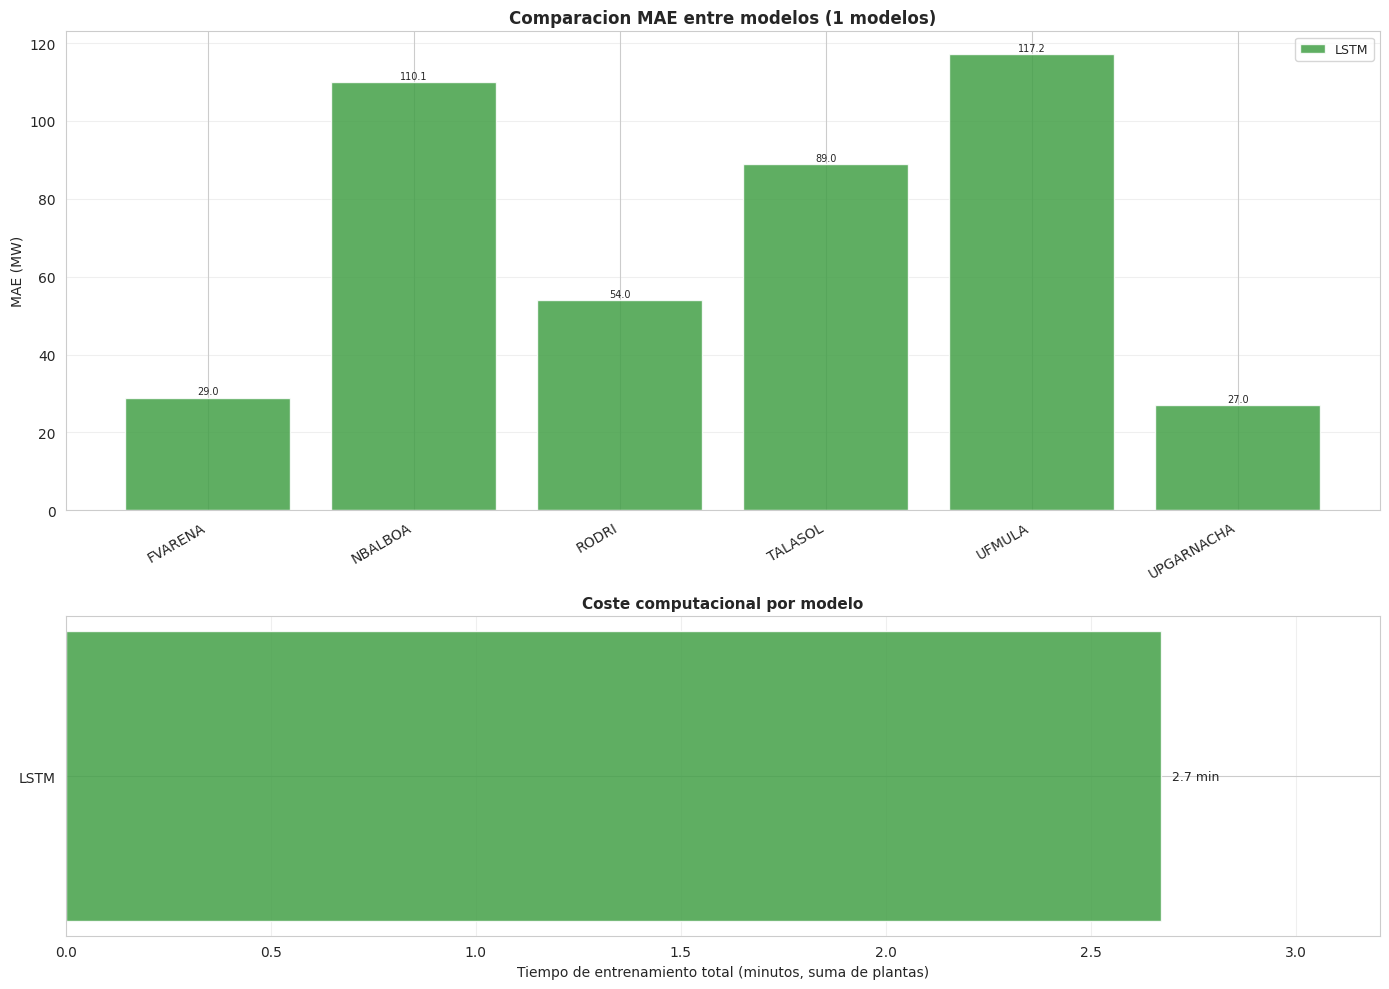

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/metrics/comparison_all_models.csv


In [10]:
# ============================================================================
# 5. COMPARACIÓN ENTRE MODELOS
# ============================================================================

print(f"\n[5/5] Comparación entre modelos disponibles")
print("="*80)

plot_model_comparison(df_metrics_lstm, 'lstm', save_dir=rm.figures_dir)


GENERANDO VISUALIZACIONES
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/UPGARNACHA_diagnostic.png


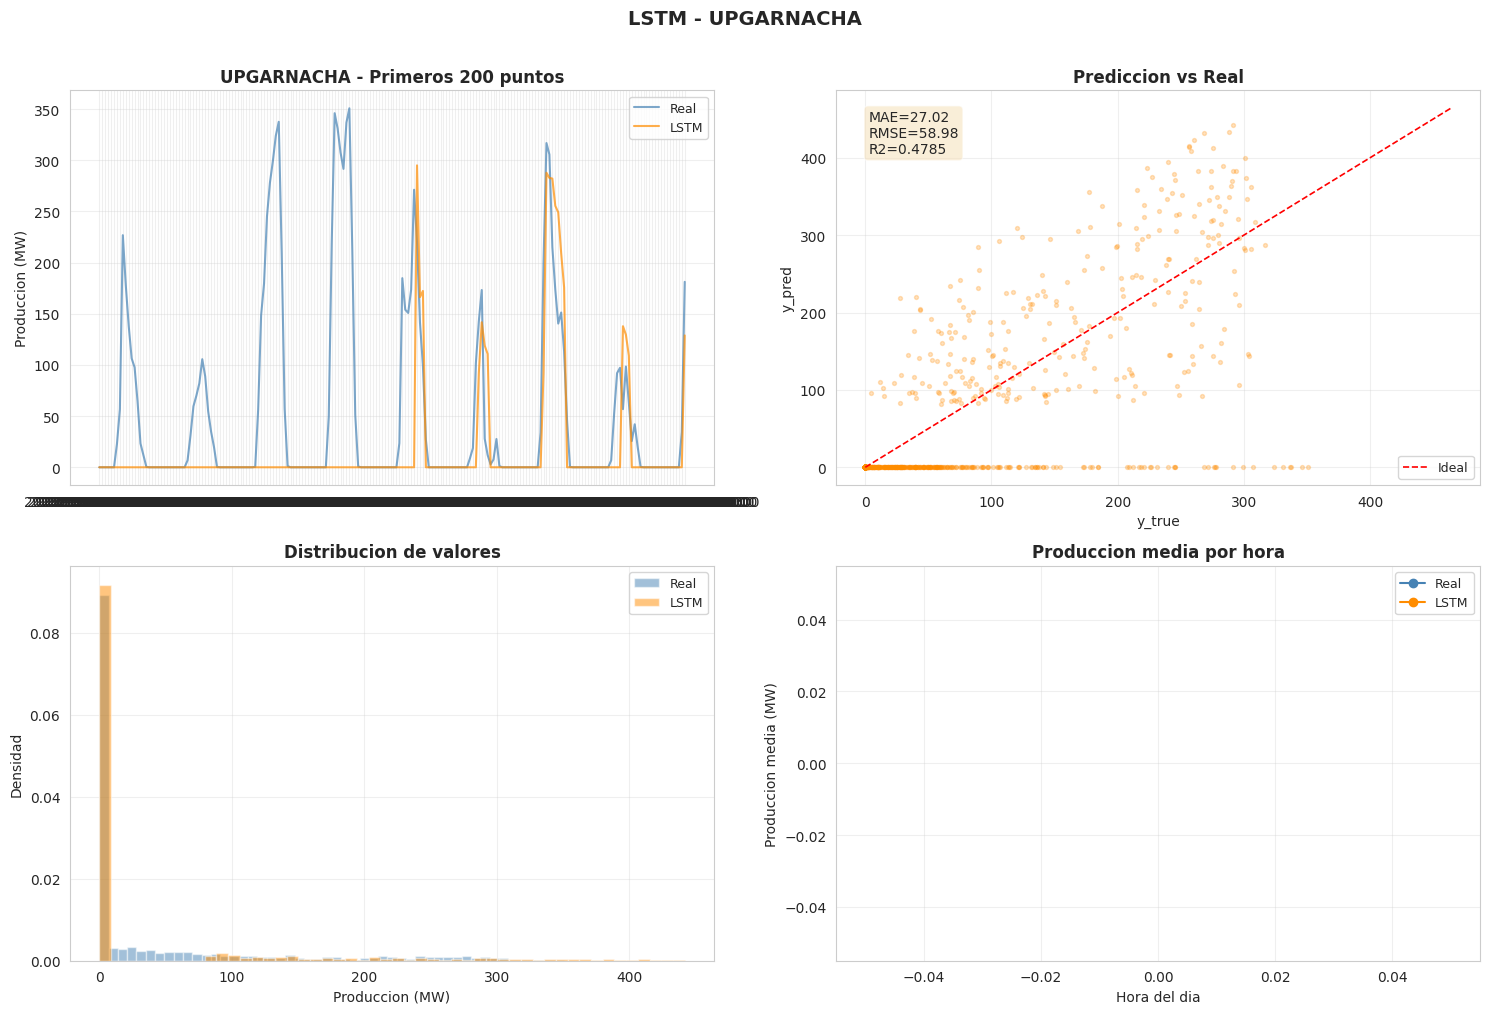

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/UPGARNACHA_timeseries.png


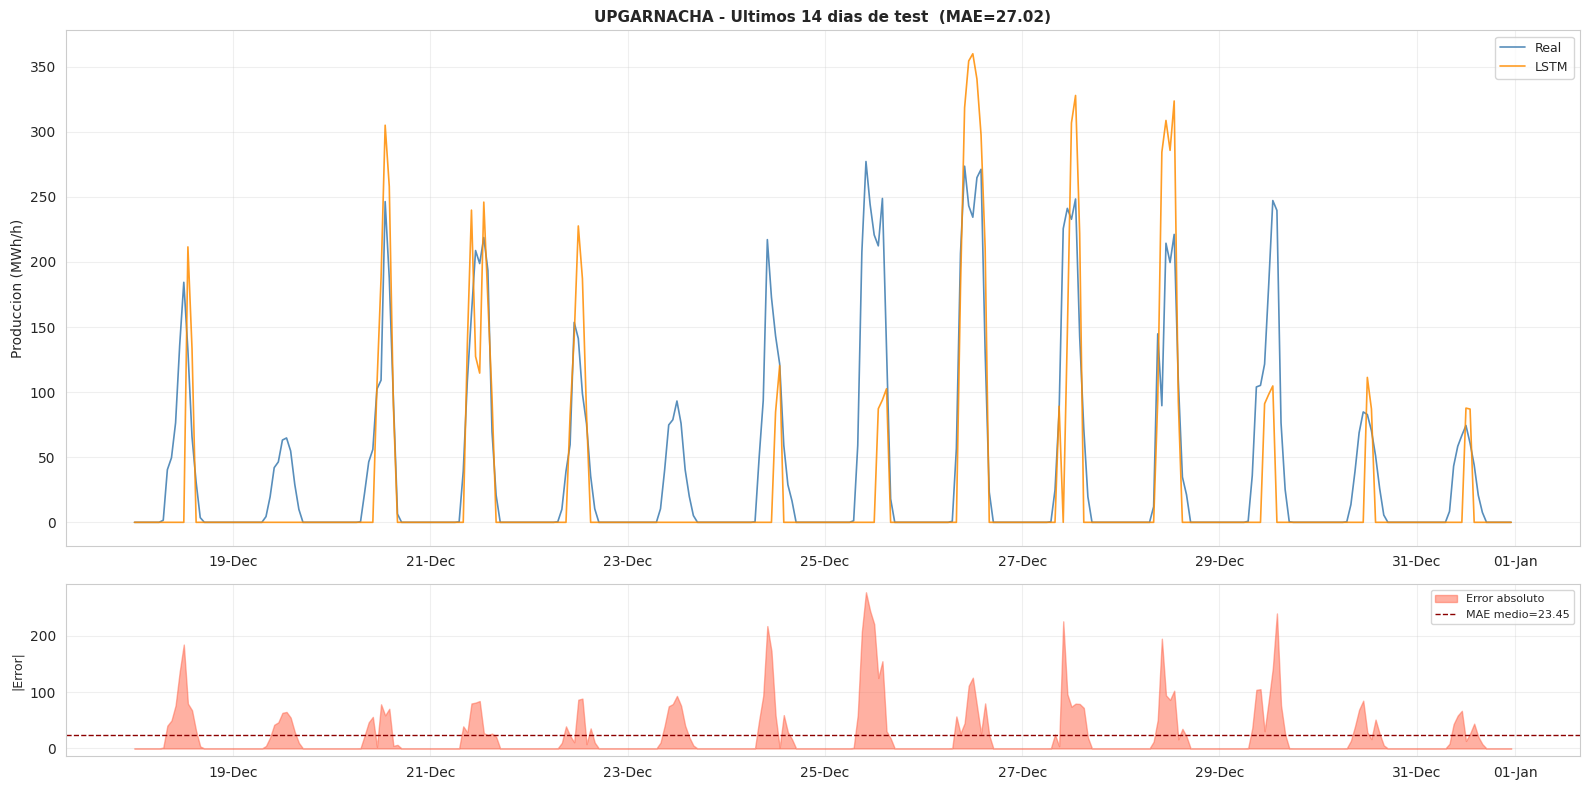

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/FVARENA_diagnostic.png


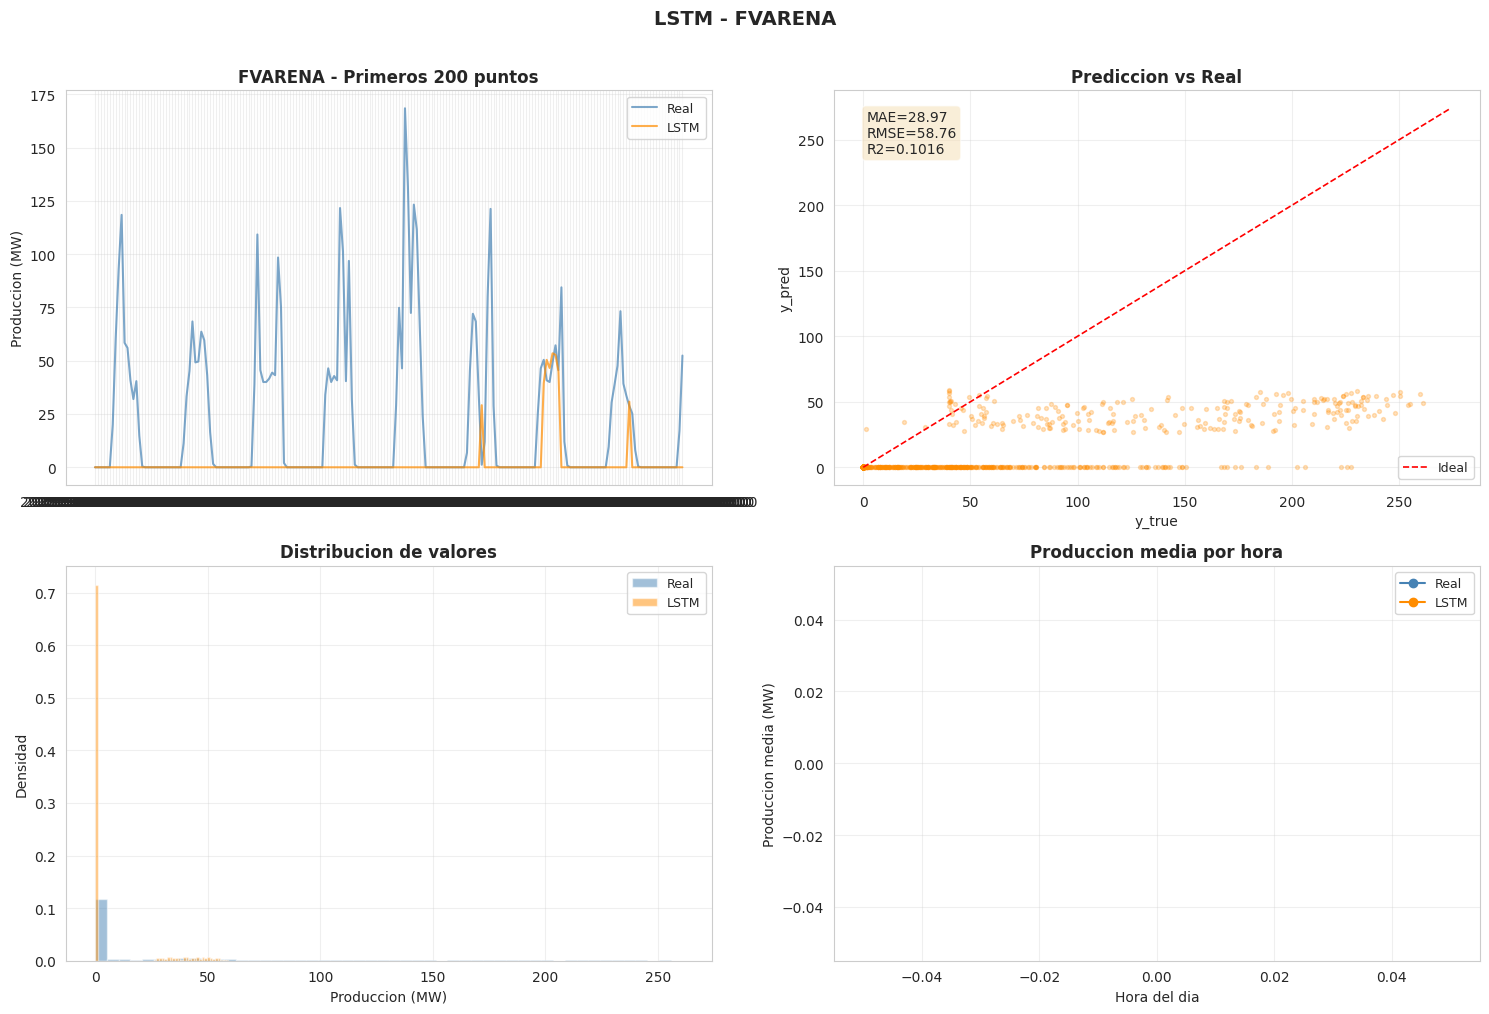

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/FVARENA_timeseries.png


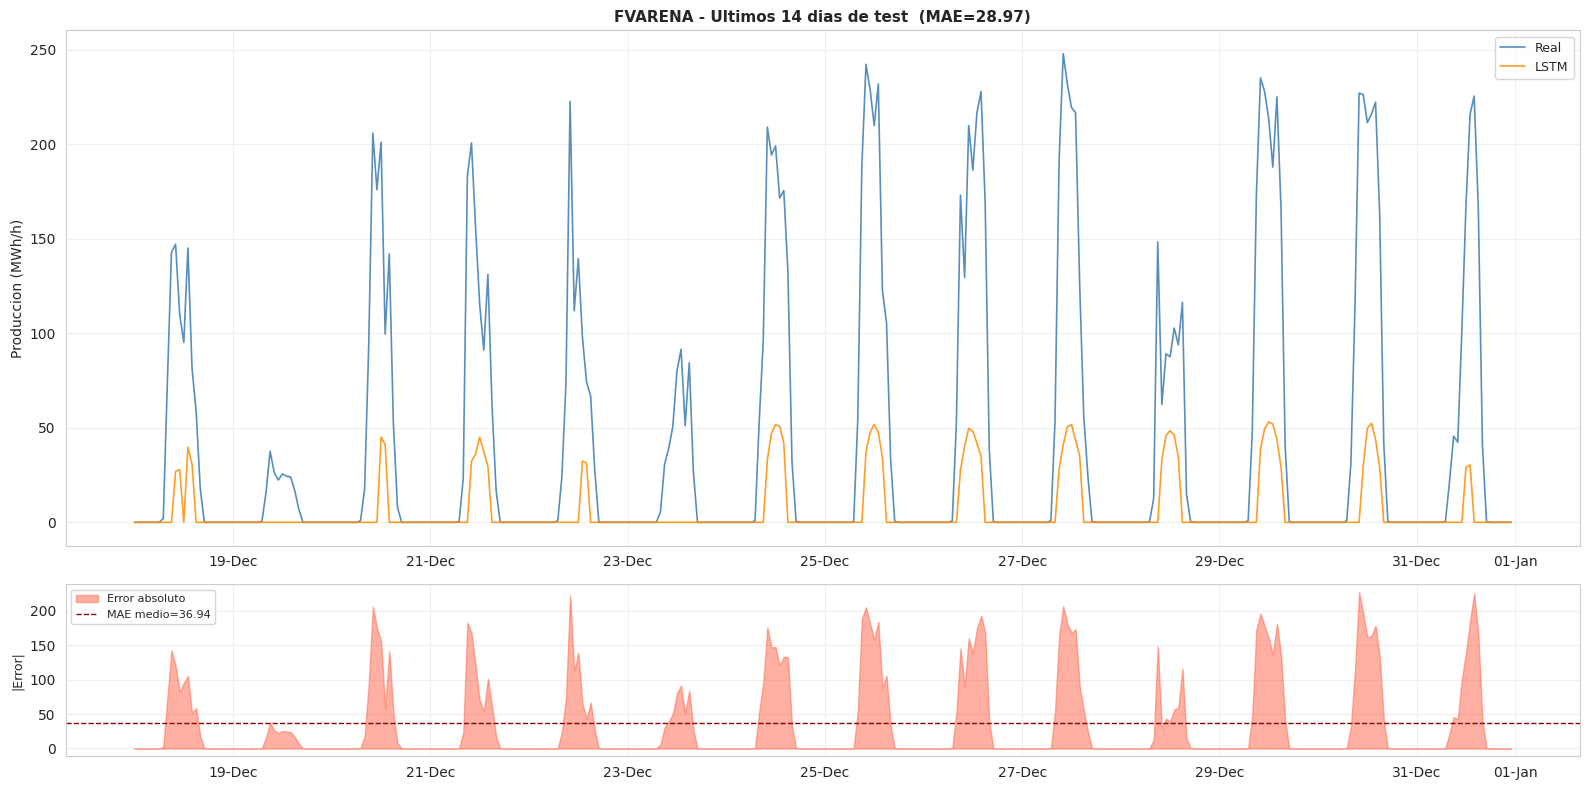

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/NBALBOA_diagnostic.png


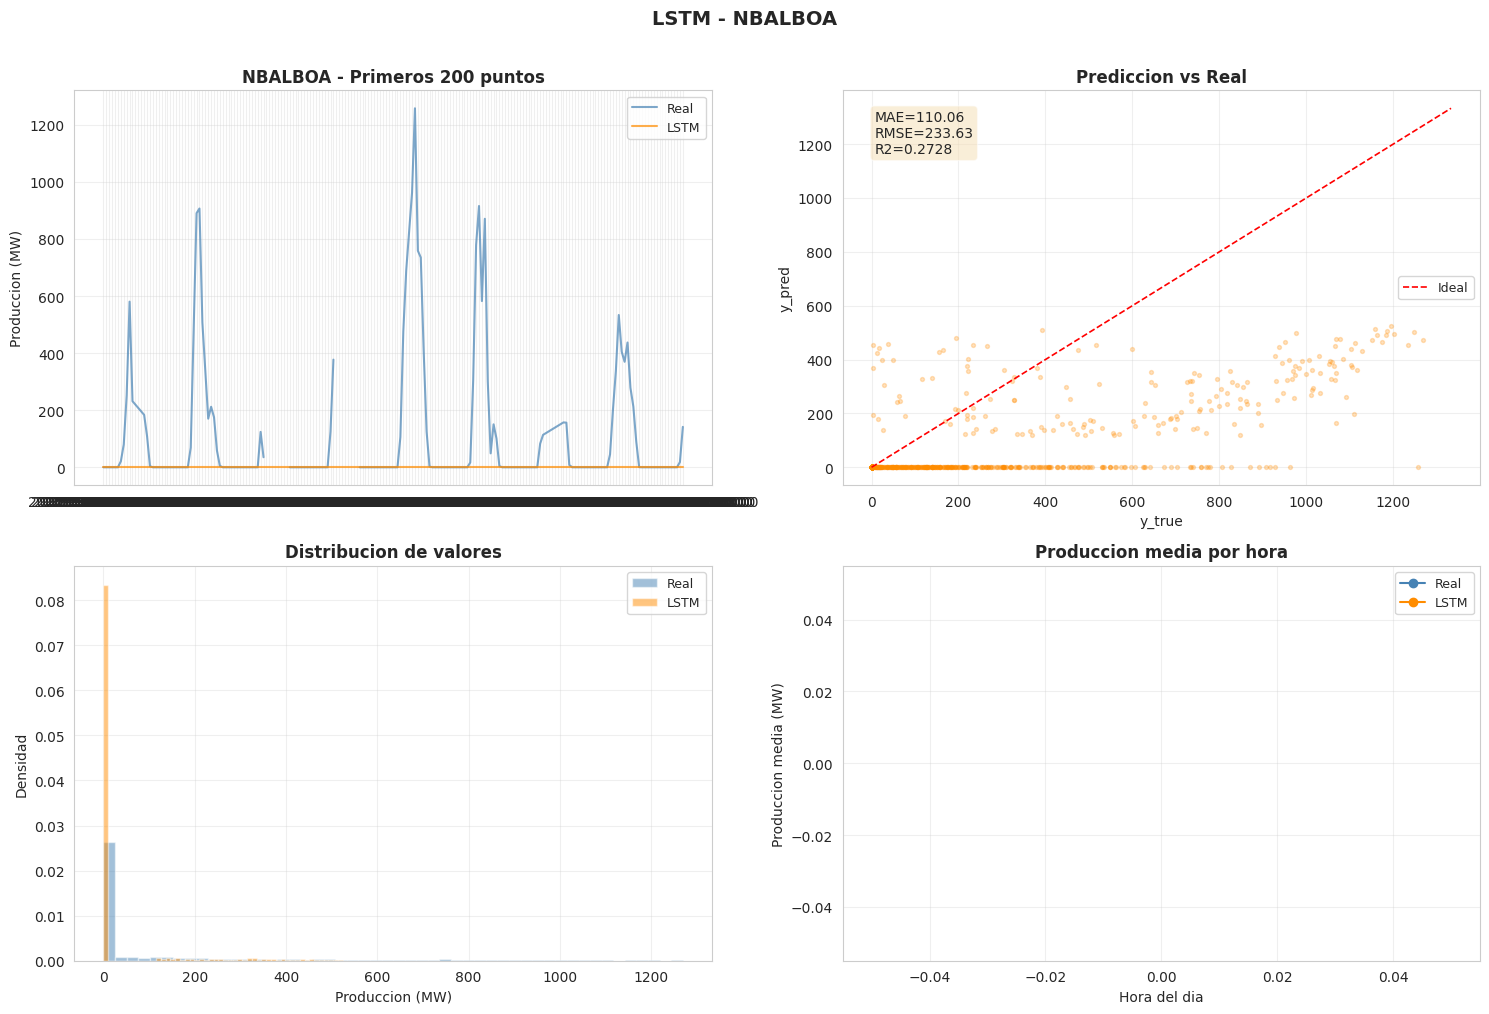

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/NBALBOA_timeseries.png


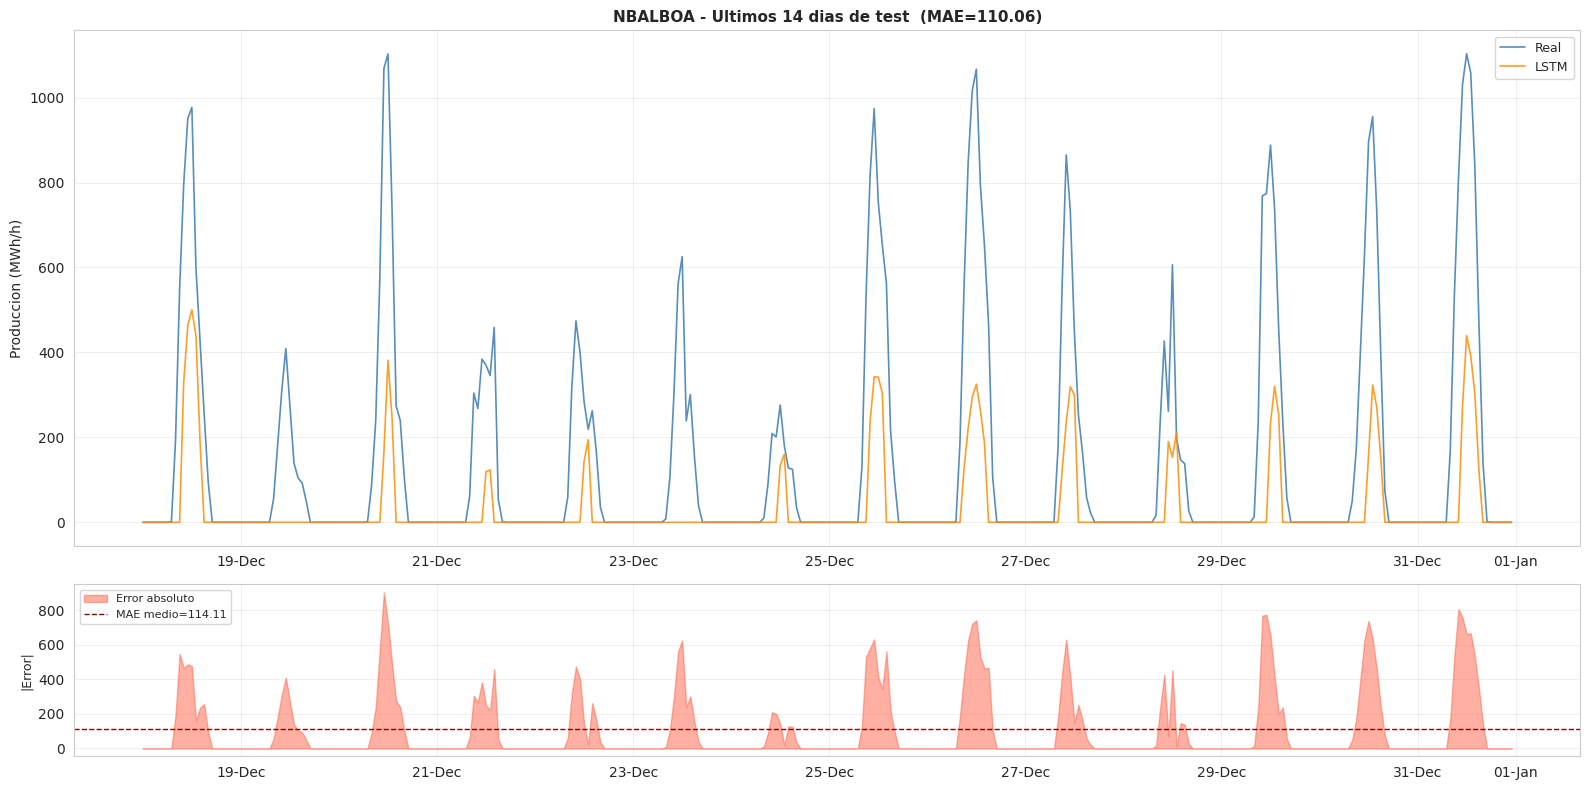

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/RODRI_diagnostic.png


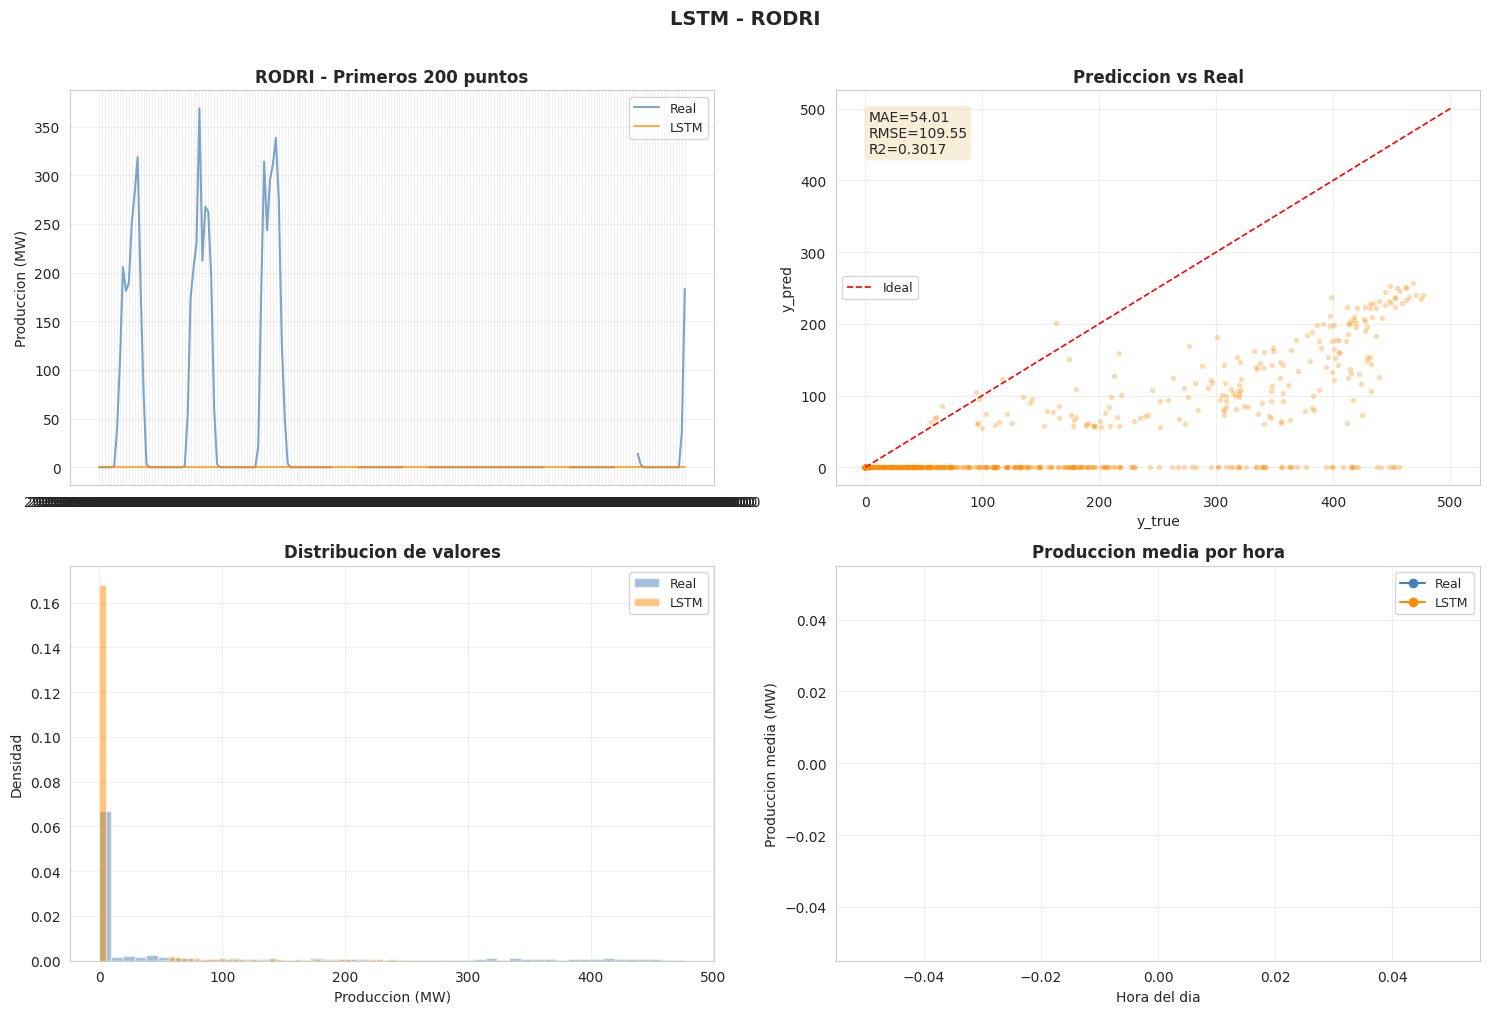

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/RODRI_timeseries.png


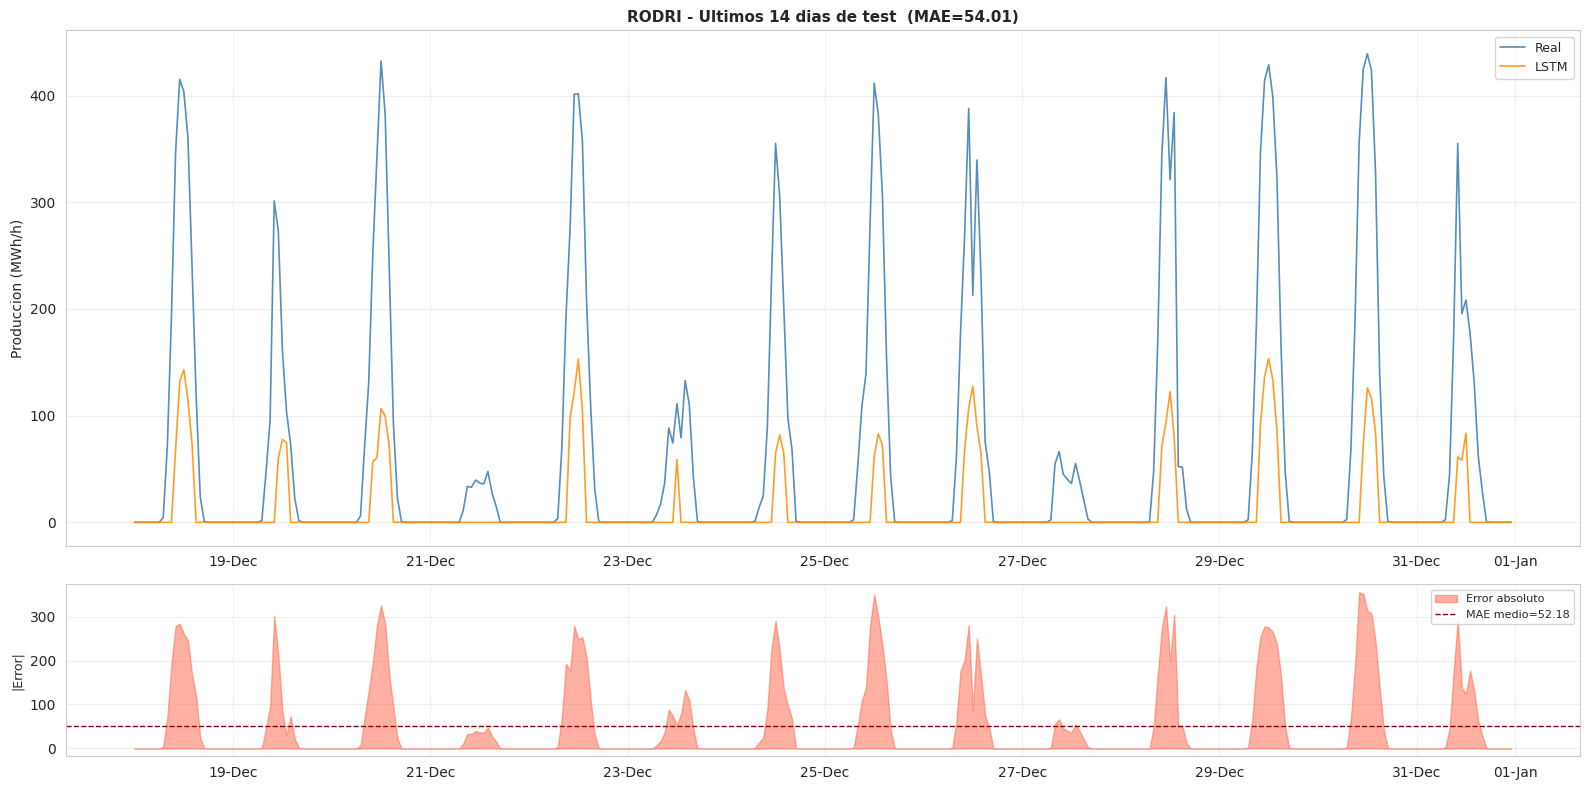

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/UFMULA_diagnostic.png


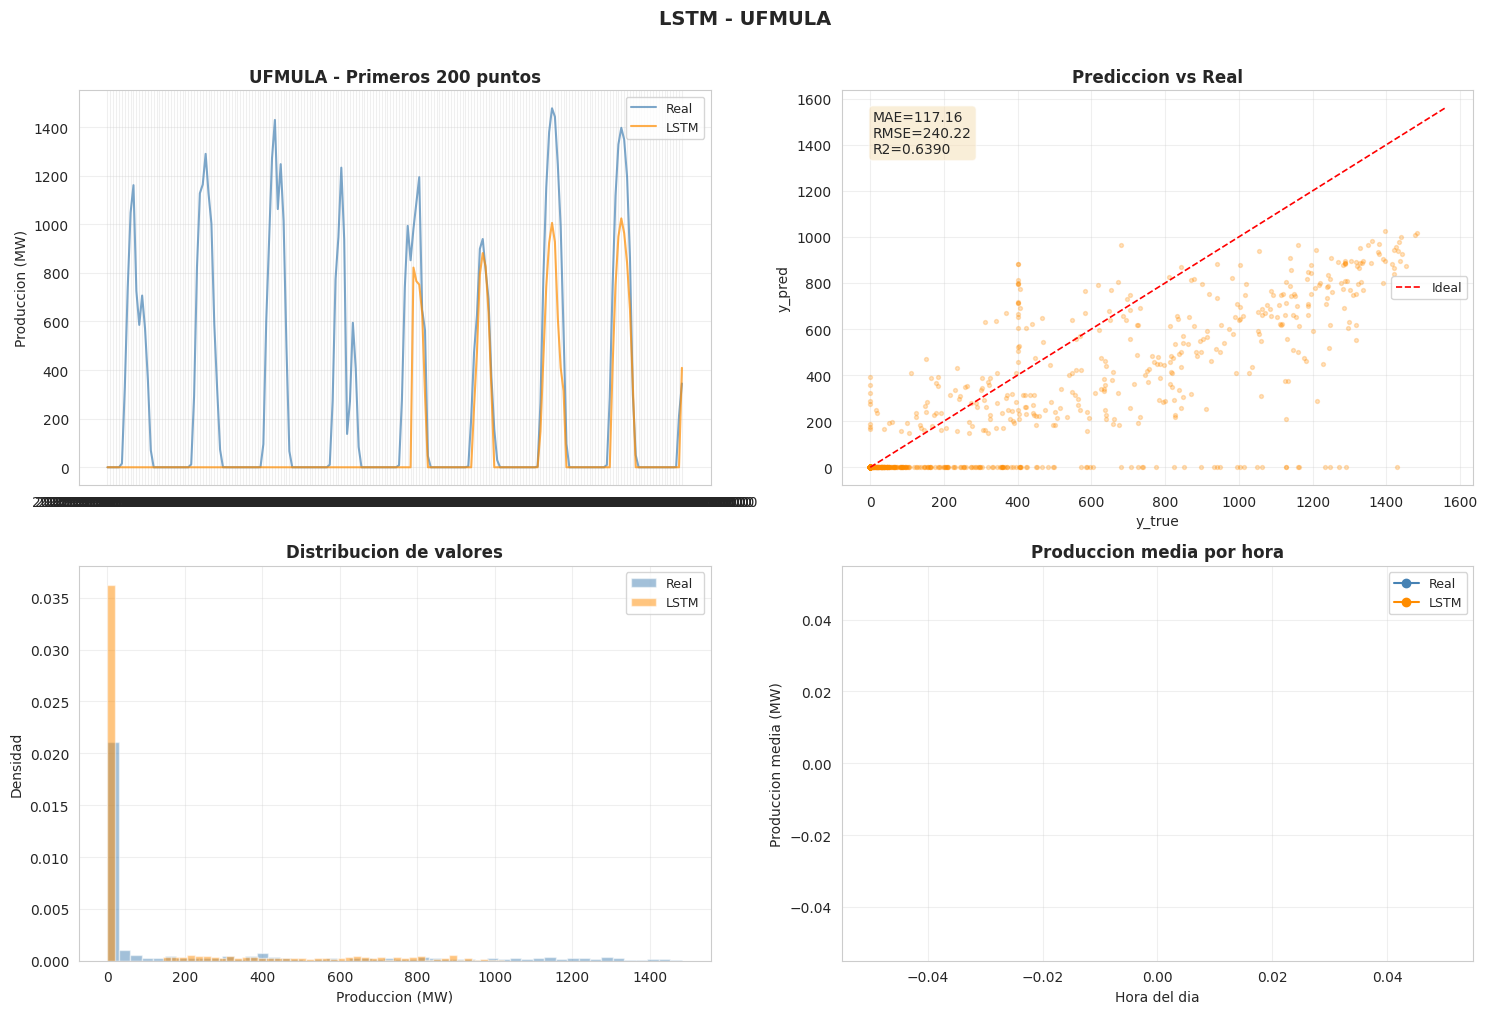

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/UFMULA_timeseries.png


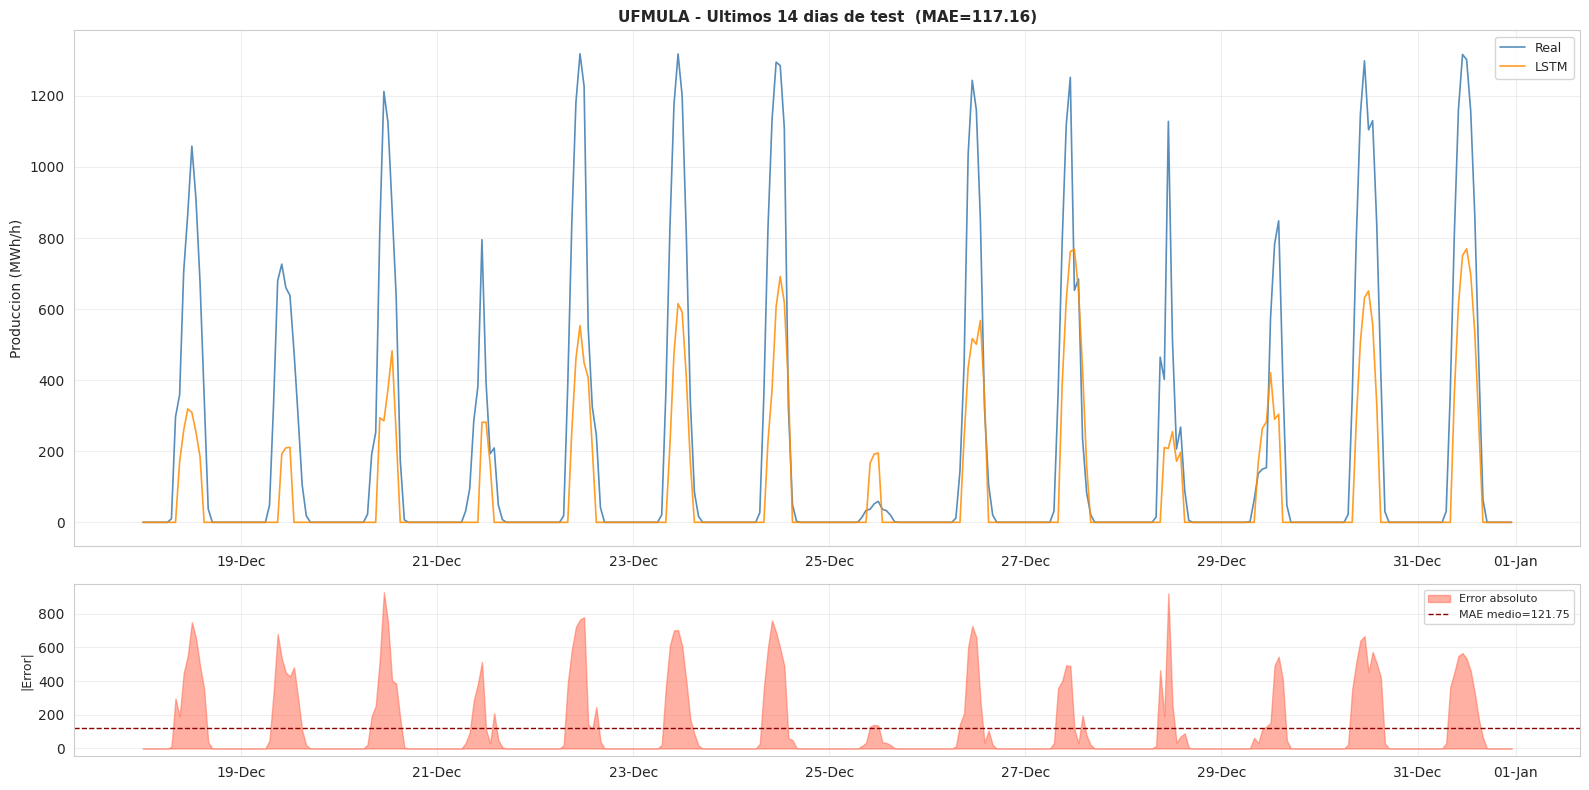

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/TALASOL_diagnostic.png


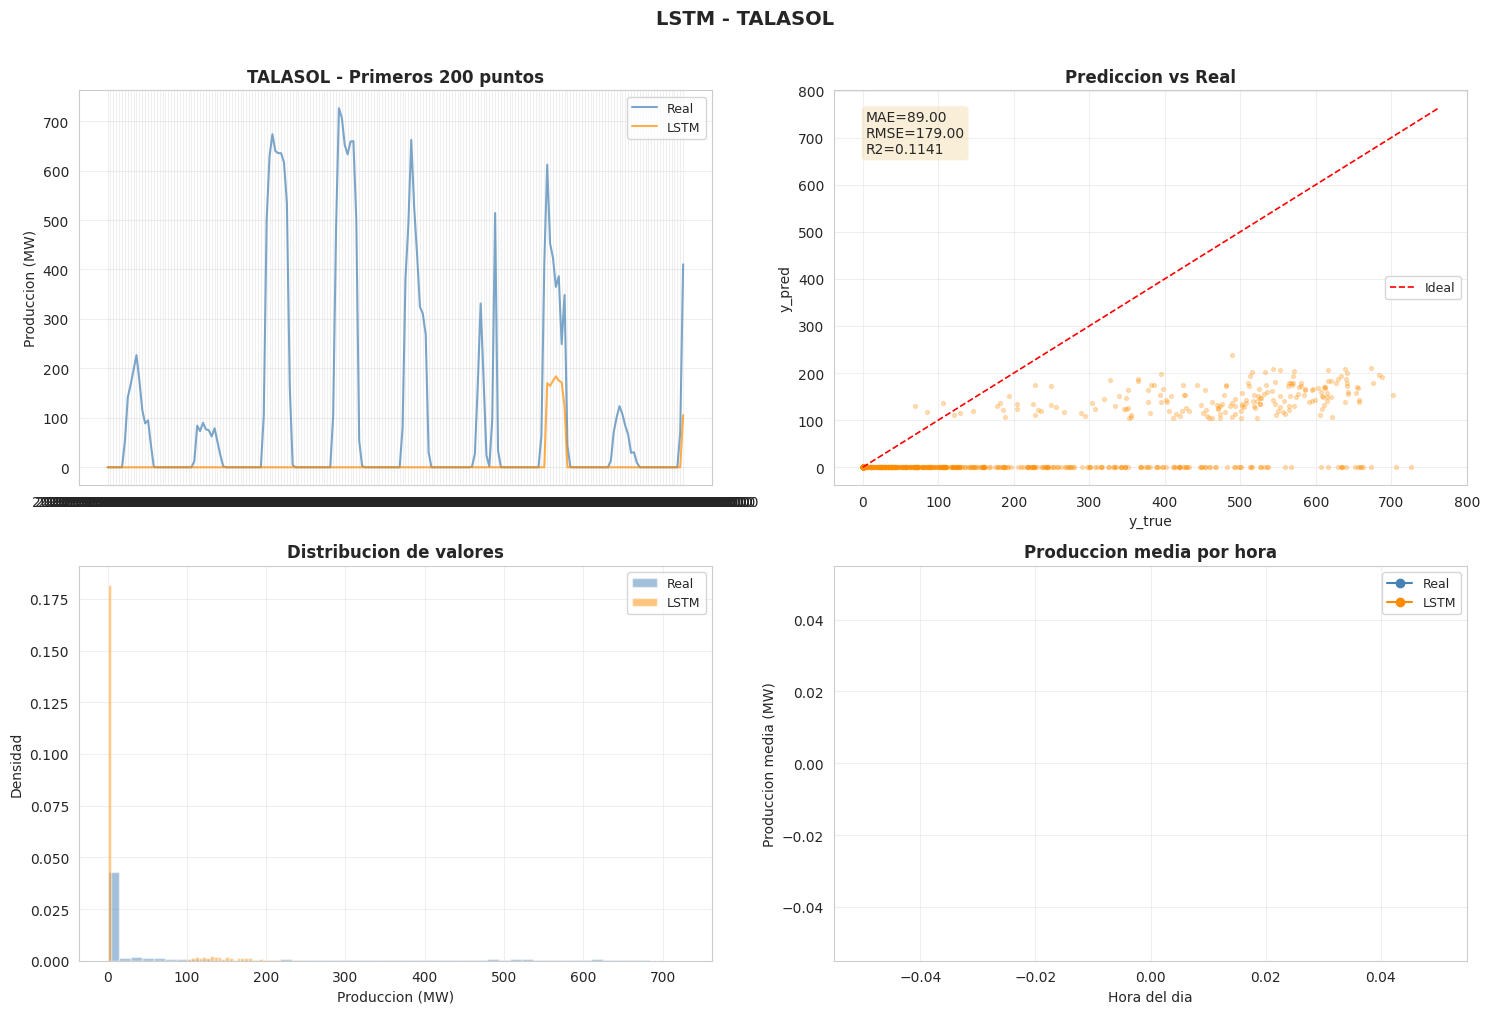

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/TALASOL_timeseries.png


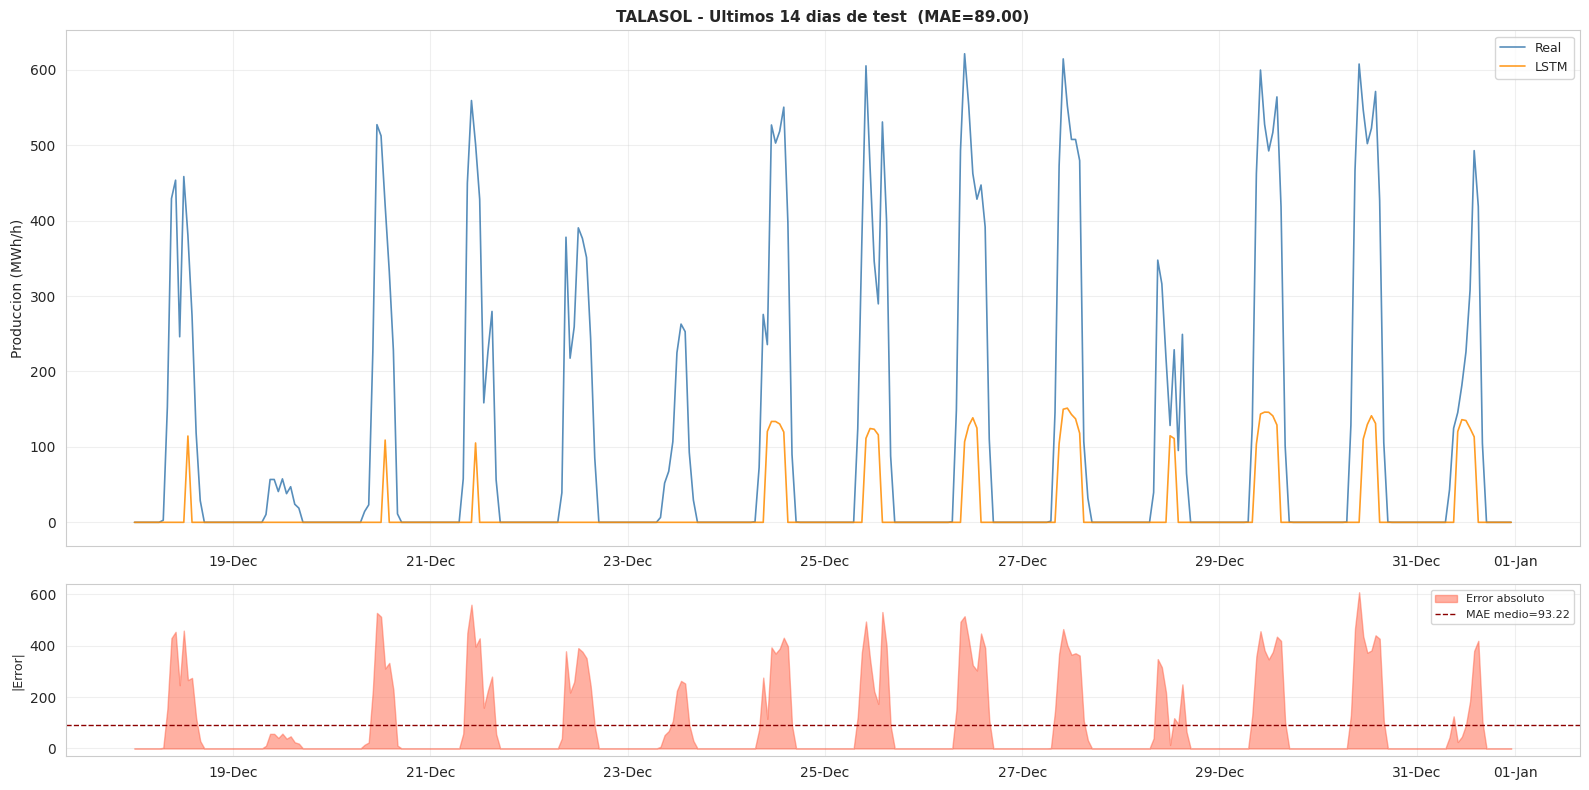


Curvas de aprendizaje...
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/UPGARNACHA_learning_curves.png


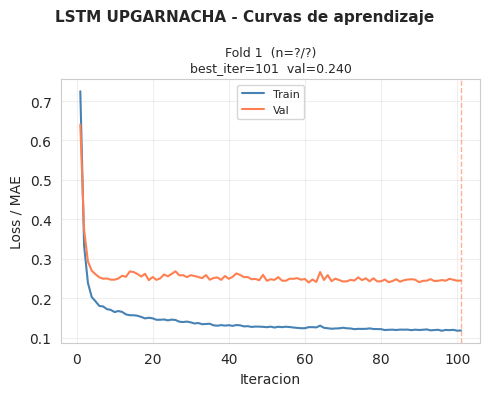

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/FVARENA_learning_curves.png


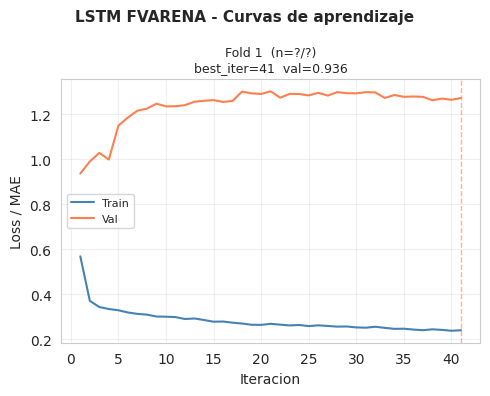

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/NBALBOA_learning_curves.png


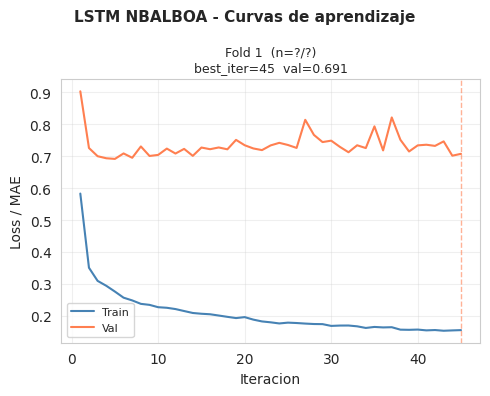

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/RODRI_learning_curves.png


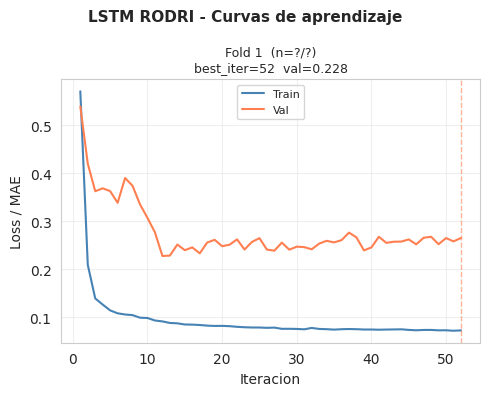

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/UFMULA_learning_curves.png


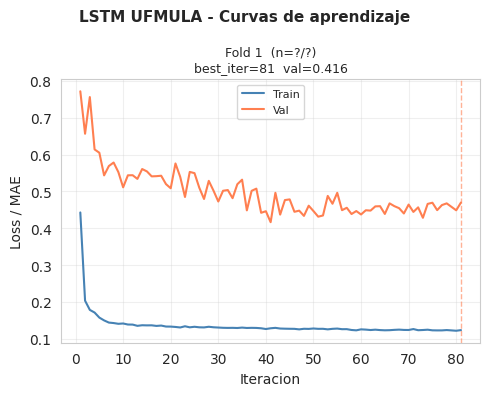

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/TALASOL_learning_curves.png


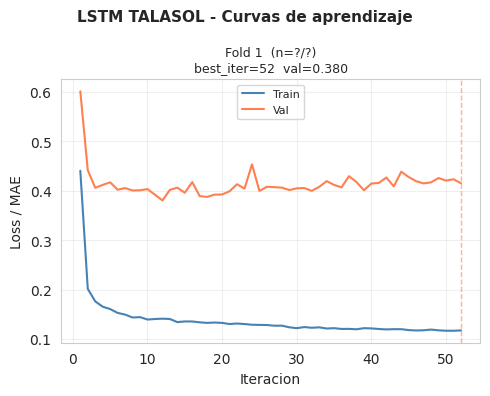


Visualizaciones guardadas en /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm


In [11]:
# ============================================================================
# 6. VISUALIZACIONES
# ============================================================================

print(f"\n{'='*80}")
print("GENERANDO VISUALIZACIONES")
print(f"{'='*80}")

for planta in plantas_p:
    df_planta = df_results[df_results['planta_nombre'] == planta]

    # Plot diagnóstico 4-panel
    plot_diagnostic(df_planta, planta, 'lstm', save_dir=rm.figures_dir)

    # Serie temporal extendida (14 días)
    plot_timeseries(df_planta, planta, 'lstm', save_dir=rm.figures_dir, days=14)

# Learning curves (visualización específica LSTM)
print("\nCurvas de aprendizaje...")
for planta in plantas_p:
    fold_hists = all_fold_hists[planta]
    if fold_hists is not None:
        plot_learning_curves(fold_hists, planta, 'lstm', save_dir=rm.figures_dir)
    elif hasattr(all_models[planta], 'train_losses'):
        # Split fijo: crear historial sintético
        trainer = all_models[planta]
        hist = [{
            'fold': 1,
            'train_mae_curve': trainer.train_losses,
            'val_mae_curve': trainer.val_losses,
            'best_iter': len(trainer.train_losses),
            'best_val_loss': min(trainer.val_losses) if trainer.val_losses else 0,
            'n_train': '?', 'n_val': '?',
        }]
        plot_learning_curves(hist, planta, 'lstm', save_dir=rm.figures_dir)

print(f"\nVisualizaciones guardadas en {rm.figures_dir}")

In [12]:
# ============================================================================
# 7. RESUMEN FINAL
# ============================================================================

print(f"\n{'='*80}")
print("EXPERIMENTO COMPLETADO")
print(f"{'='*80}")

print(f"\nResultados LSTM:")
print(f"  Plantas procesadas: {len(plantas_p)}")
print(f"  MAE promedio:  {df_metrics_lstm['MAE'].mean():.4f} h equiv.")
print(f"  Mejor planta:  {df_metrics_lstm.iloc[0]['planta']} (MAE: {df_metrics_lstm.iloc[0]['MAE']:.4f})")

print(f"\nArchivos generados en {rm.results_dir}:")
print(f"  Metricas:    {rm.metrics_dir}/")
print(f"  Figuras:     {rm.figures_dir}/")
print(f"  Checkpoints: {rm.ckpt_dir}/")

print("\nPipeline LSTM completado")
print("="*80)


EXPERIMENTO COMPLETADO

Resultados LSTM:
  Plantas procesadas: 6
  MAE promedio:  71.0369 h equiv.
  Mejor planta:  UPGARNACHA (MAE: 27.0194)

Archivos generados en /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare:
  Metricas:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/lstm/
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/lstm/

Pipeline LSTM completado
